In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("GlimpseSize_3_GridSize_32.csv")
sns.lineplot(data=df, x="epoch", y="accuracy", hue="glimpses")

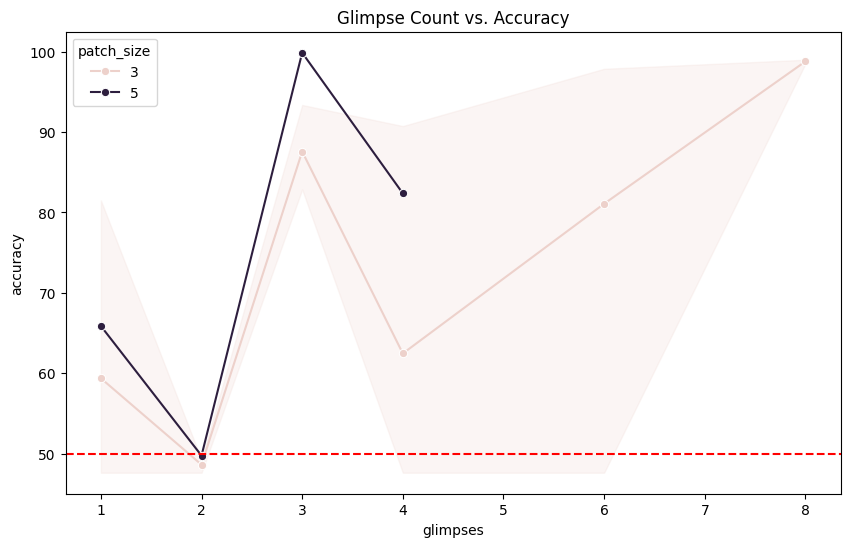

In [13]:
import seaborn as sns
df1 = pd.read_csv("glimpse_experiment_results1.csv")
# Filter for final accuracy per run
final_df = df[df['epoch'] == 150]

plt.figure(figsize=(10,6))
sns.lineplot(data=final_df, x="glimpses", y="accuracy", hue="patch_size", marker="o")
plt.axhline(50, ls='--', color='red', label="Chance")
plt.title("Glimpse Count vs. Accuracy")
plt.show()

Plot successfully saved as hpc_results_final.png


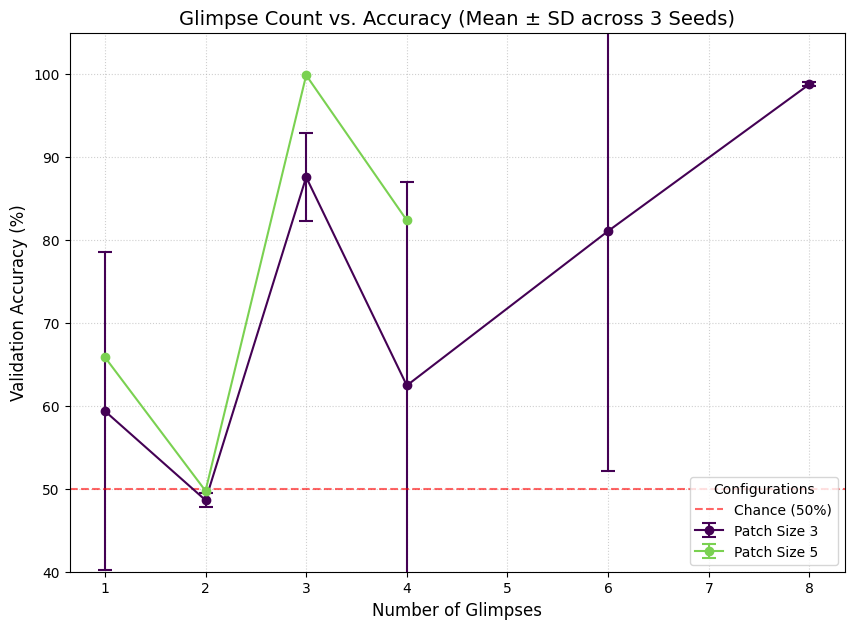

In [11]:
# Filter for final accuracy (max epoch)
max_epoch = df['epoch'].max()
final_df = df[df['epoch'] == max_epoch]

# 2. Group by Patch Size and Glimpses to get Mean and Std Dev
stats = final_df.groupby(['patch_size', 'glimpses'])['accuracy'].agg(['mean', 'std']).reset_index()

# 3. Plotting with Matplotlib
plt.figure(figsize=(10, 7))

# Get unique patch sizes for looping
patch_sizes = sorted(stats['patch_size'].unique())
colors = plt.cm.viridis(np.linspace(0, 0.8, len(patch_sizes)))

for i, p_size in enumerate(patch_sizes):
    subset = stats[stats['patch_size'] == p_size]
    
    # errorbar arguments:
    # yerr: standard deviation
    # fmt: format (line + marker)
    # capsize: the width of the horizontal whiskers (in points)
    # elinewidth: thickness of the vertical line
    plt.errorbar(
        subset['glimpses'], 
        subset['mean'], 
        yerr=subset['std'], 
        label=f"Patch Size {p_size}",
        fmt='-o',
        color=colors[i],
        capsize=5,          # This gives you the discrete box-plot caps
        capthick=1.5,
        elinewidth=1.5,
        markersize=6
    )

# 4. Formatting
plt.axhline(50, color='red', linestyle='--', alpha=0.6, label="Chance (50%)")
plt.title(f"Glimpse Count vs. Accuracy (Mean ± SD across {len(final_df['seed'].unique())} Seeds)", fontsize=14)
plt.xlabel("Number of Glimpses", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.ylim(40, 105) # Ensure there's room for error bars
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Configurations", loc='lower right')

plt.savefig("hpc_results_final.png", dpi=300)
print("Plot successfully saved as hpc_results_final.png")
plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1020818/511383514.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)


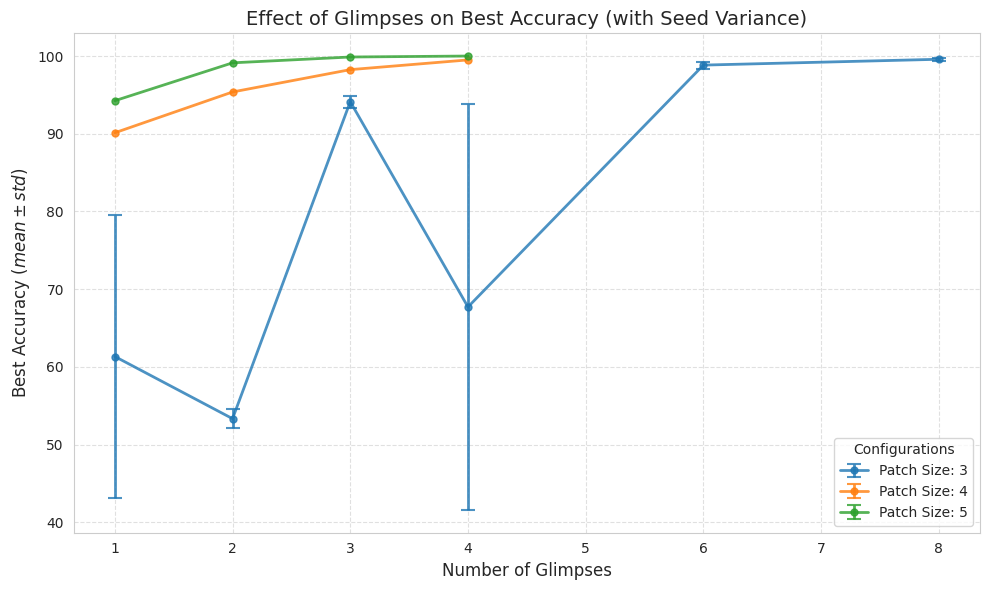

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and combine the data
df1 = pd.read_csv("glimpse_experiment_results1.csv")
df2 = pd.read_csv("glimpse_experiment_results2.csv")
df = pd.concat([df1, df2], ignore_index=True)

# 2. Get the final/best accuracy for each specific run (seed)
# We group by patch_size, glimpses, and seed to find the max accuracy reached in that run
df_runs = df.groupby(['patch_size', 'glimpses', 'seed'])['best_accuracy'].max().reset_index()

# 3. Calculate Mean and Standard Deviation across seeds
# This gives us the "smooth curve" (mean) and "variance" (std)
stats = df_runs.groupby(['patch_size', 'glimpses'])['best_accuracy'].agg(['mean', 'std']).reset_index()

# 4. Plotting with Matplotlib
plt.figure(figsize=(10, 6))

# Loop through each patch size to overplot them
for patch_size in stats['patch_size'].unique():
    subset = stats[stats['patch_size'] == patch_size]
    
    plt.errorbar(
        subset['glimpses'], 
        subset['mean'], 
        yerr=subset['std'], 
        label=f"Patch Size: {patch_size}",
        capsize=5,          # This adds the horizontal caps
        capthick=1.5,       # Thickness of the caps
        marker='o',         # Adds dots to the mean values
        markersize=5,
        linestyle='-',      # Creates the smooth curve
        linewidth=2,
        alpha=0.8           # Slight transparency to see overlapping lines
    )

# Formatting the plot
plt.title("Effect of Glimpses on Best Accuracy (with Seed Variance)", fontsize=14)
plt.xlabel("Number of Glimpses", fontsize=12)
plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.tight_layout()

# Save and Show
plt.savefig("glimpse_results_matplotlib.png", dpi=300)
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1295626/3355772759.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)


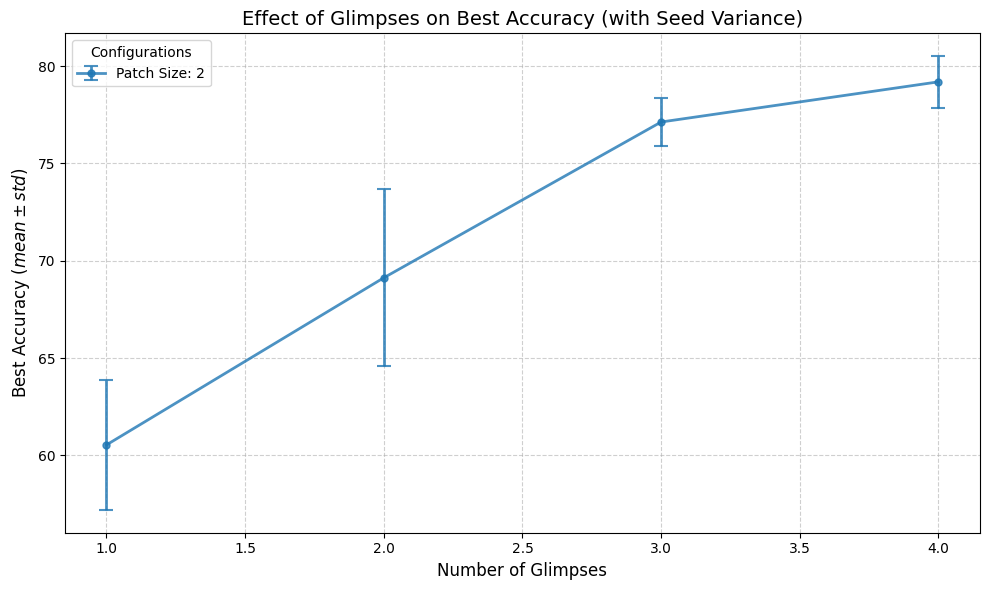

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../csv-files/training_data_LR_0.0001_cleaned.csv")

df_runs = df.groupby(['patch_size', 'glimpses', 'seed'])['best_accuracy'].max().reset_index()

stats = df_runs.groupby(['patch_size', 'glimpses'])['best_accuracy'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))

for patch_size in stats['patch_size'].unique():
    subset = stats[stats['patch_size'] == patch_size]
    
    plt.errorbar(
        subset['glimpses'], 
        subset['mean'], 
        yerr=subset['std'], 
        label=f"Patch Size: {patch_size}",
        capsize=5,          # This adds the horizontal caps
        capthick=1.5,       # Thickness of the caps
        marker='o',         # Adds dots to the mean values
        markersize=5,
        linestyle='-',      # Creates the smooth curve
        linewidth=2,
        alpha=0.8           # Slight transparency to see overlapping lines
    )

plt.title("Effect of Glimpses on Best Accuracy (with Seed Variance)", fontsize=14)
plt.xlabel("Number of Glimpses", fontsize=12)
plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.tight_layout()

#plt.savefig("glimpse_results_matplotlib.png", dpi=300)
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1295626/12442713.py:28: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)


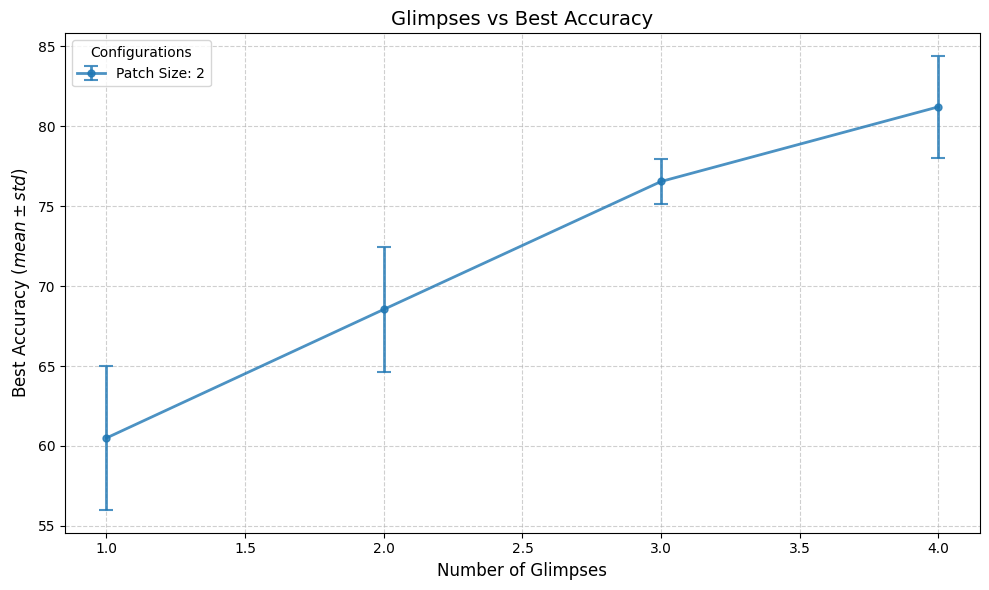

In [14]:
df = pd.read_csv("../csv-files/results_lr0.001.csv")

df_runs = df.groupby(['patch_size', 'glimpses', 'seed'])['best_accuracy'].max().reset_index()

stats = df_runs.groupby(['patch_size', 'glimpses'])['best_accuracy'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))

for patch_size in stats['patch_size'].unique():
    subset = stats[stats['patch_size'] == patch_size]
    
    plt.errorbar(
        subset['glimpses'], 
        subset['mean'], 
        yerr=subset['std'], 
        label=f"Patch Size: {patch_size}",
        capsize=5,          # This adds the horizontal caps
        capthick=1.5,       # Thickness of the caps
        marker='o',         # Adds dots to the mean values
        markersize=5,
        linestyle='-',      # Creates the smooth curve
        linewidth=2,
        alpha=0.8           # Slight transparency to see overlapping lines
    )

plt.title("Glimpses vs Best Accuracy", fontsize=14)
plt.xlabel("Number of Glimpses", fontsize=12)
plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.tight_layout()

#plt.savefig("glimpse_results_matplotlib.png", dpi=300)
plt.show()

Seed counts:
seed
1    800
2    800
3    800
4    800
5    800
6    800
Name: count, dtype: int64
Seed 1: 800 lines
Seed 2: 800 lines
Seed 3: 800 lines


<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1295626/1672353287.py:43: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)


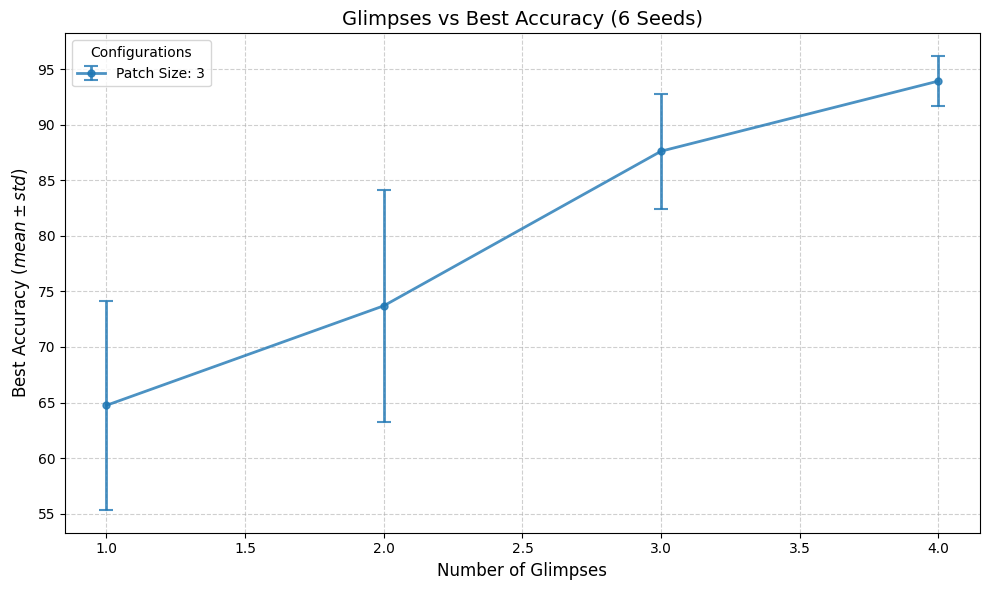

In [12]:
df1 = pd.read_csv("../csv-files/results_lr0.0001.csv")
df2 = pd.read_csv("../csv-files/results2_lr0.0001.csv")

df = pd.concat([df1, df2], ignore_index=True)

df_runs = df.groupby(['patch_size', 'glimpses', 'seed'])['best_accuracy'].max().reset_index()
# 2. Count the number of lines for each seed
# This assumes your column name is exactly 'seed'
seed_counts = df['seed'].value_counts()

# 3. Display the results
print("Seed counts:")
print(seed_counts)

# If you want to see them in a specific order (e.g., 1, 2, 3)
for seed in [1, 2, 3]:
    count = seed_counts.get(seed, 0)
    print(f"Seed {seed}: {count} lines")

stats = df_runs.groupby(['patch_size', 'glimpses'])['best_accuracy'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))

for patch_size in stats['patch_size'].unique():
    subset = stats[stats['patch_size'] == patch_size]
    
    plt.errorbar(
        subset['glimpses'], 
        subset['mean'], 
        yerr=subset['std'], 
        label=f"Patch Size: {patch_size}",
        capsize=5,          # This adds the horizontal caps
        capthick=1.5,       # Thickness of the caps
        marker='o',         # Adds dots to the mean values
        markersize=5,
        linestyle='-',      # Creates the smooth curve
        linewidth=2,
        alpha=0.8           # Slight transparency to see overlapping lines
    )

plt.title("Glimpses vs Best Accuracy (6 Seeds)", fontsize=14)
plt.xlabel("Number of Glimpses", fontsize=12)
plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.tight_layout()

#plt.savefig("glimpse_results_matplotlib.png", dpi=300)
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1295626/3047098608.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)


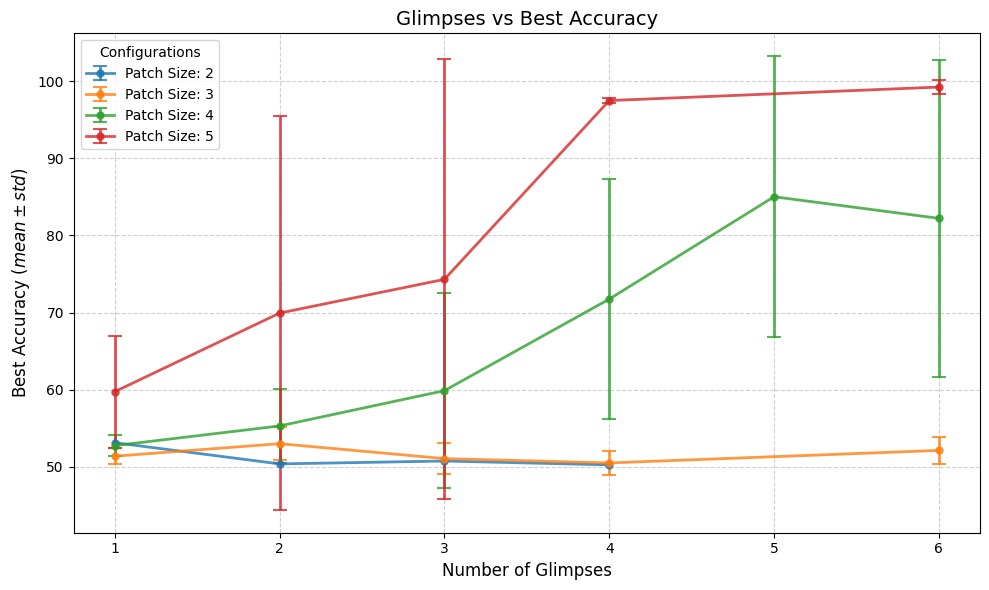

In [17]:
df1 = pd.read_csv("../csv-files/results_staticmask_lr0.001.csv")
df2 = pd.read_csv("../csv-files/results_staticmask2_lr0.001.csv")

df = pd.concat([df1, df2], ignore_index=True)

df_runs = df.groupby(['patch_size', 'glimpses', 'seed'])['best_accuracy'].max().reset_index()

stats = df_runs.groupby(['patch_size', 'glimpses'])['best_accuracy'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))

for patch_size in stats['patch_size'].unique():
    subset = stats[stats['patch_size'] == patch_size]
    
    plt.errorbar(
        subset['glimpses'], 
        subset['mean'], 
        yerr=subset['std'], 
        label=f"Patch Size: {patch_size}",
        capsize=5,          # This adds the horizontal caps
        capthick=1.5,       # Thickness of the caps
        marker='o',         # Adds dots to the mean values
        markersize=5,
        linestyle='-',      # Creates the smooth curve
        linewidth=2,
        alpha=0.8           # Slight transparency to see overlapping lines
    )

plt.title("Glimpses vs Best Accuracy", fontsize=14)
plt.xlabel("Number of Glimpses", fontsize=12)
plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.tight_layout()

#plt.savefig("glimpse_results_matplotlib.png", dpi=300)
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1295626/1700470053.py:32: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)


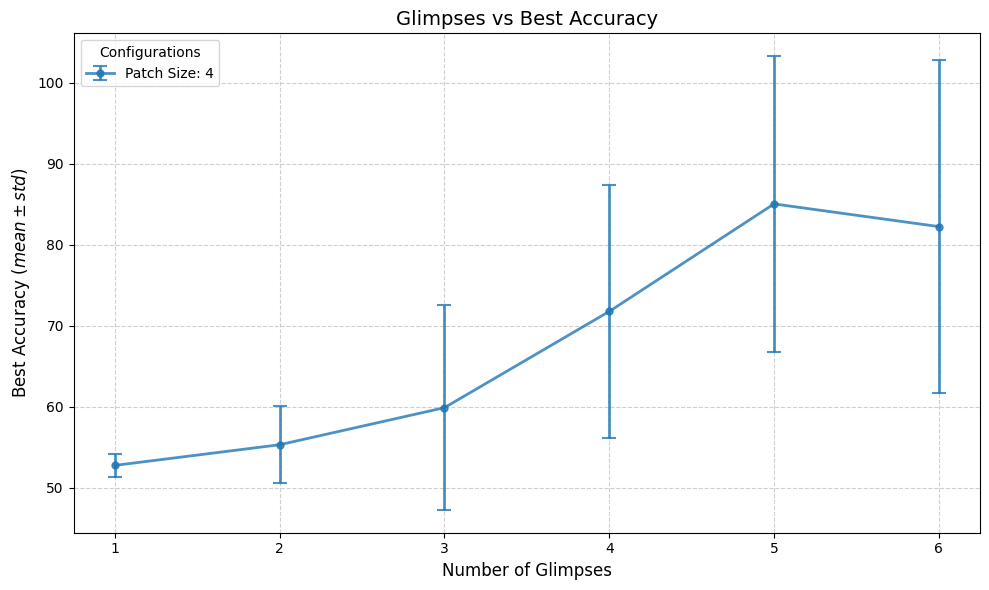

In [ ]:
df1 = pd.read_csv("../csv-files/results_staticmask_lr0.001.csv")
df2 = pd.read_csv("../csv-files/results_staticmask2_lr0.001.csv")

df = pd.concat([df1, df2], ignore_index=True)

df_runs = df.groupby(['patch_size', 'glimpses', 'seed'])['best_accuracy'].max().reset_index()

stats = df_runs.groupby(['patch_size', 'glimpses'])['best_accuracy'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))

patch_size = 4

subset = stats[stats['patch_size'] == patch_size]
    
plt.errorbar(
    subset['glimpses'], 
    subset['mean'], 
    yerr=subset['std'], 
    label=f"Patch Size: {patch_size}",
    capsize=5,          # This adds the horizontal caps
    capthick=1.5,       # Thickness of the caps
    marker='o',         # Adds dots to the mean values
    markersize=5,
    linestyle='-',      # Creates the smooth curve
    linewidth=2,
    alpha=0.8           # Slight transparency to see overlapping lines
)

plt.title("Glimpses vs Best Accuracy", fontsize=14)
plt.xlabel("Number of Glimpses", fontsize=12)
plt.ylabel("Best Accuracy ($mean \pm std$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.tight_layout()

#plt.savefig("glimpse_results_matplotlib.png", dpi=300)
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2357441/4036954041.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Accuracy ($mean \pm std$)")
/tmp/ipykernel_2357441/4036954041.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Min Loss ($mean \pm std$)")


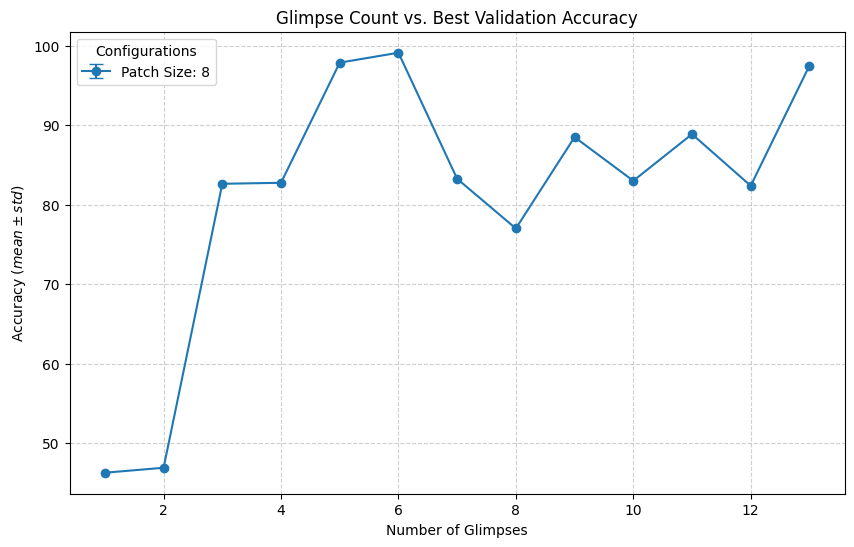

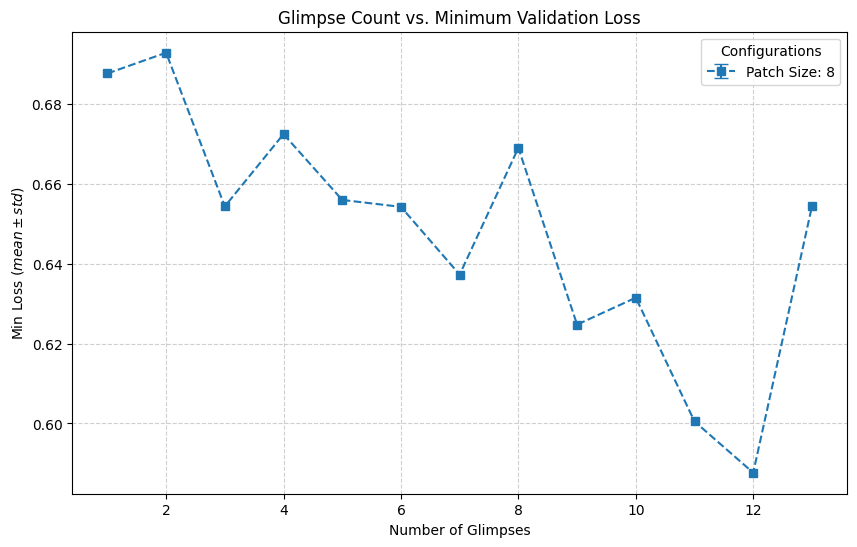

In [ ]:
df = pd.read_csv("../csv-files/results_moderatelysmall2.csv")

# Grouping logic for accuracy and loss
df_runs = df.groupby(['patch_size', 'glimpses', 'seed']).agg({
    'val_accuracy': 'max',
    'val_loss': 'min'
}).reset_index()

stats = df_runs.groupby(['patch_size', 'glimpses']).agg({
    'val_accuracy': ['mean', 'std'],
    'val_loss': ['mean', 'std']
}).reset_index()


# Plot 1: Glimpse Count vs. Best Validation Accuracy
plt.figure(figsize=(10, 6))
for ps in sorted(stats['patch_size'].unique()):
    subset = stats[stats['patch_size'] == ps]
    plt.errorbar(
        subset['glimpses'], subset[('val_accuracy', 'mean')], 
        yerr=subset[('val_accuracy', 'std')], 
        label=f"Patch Size: {ps}", capsize=5, marker='o'
    )
plt.title("Glimpse Count vs. Best Validation Accuracy")
plt.xlabel("Number of Glimpses")
plt.ylabel("Accuracy ($mean \pm std$)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")

# Plot 2: Glimpse Count vs. Minimum Validation Loss
plt.figure(figsize=(10, 6))
for ps in sorted(stats['patch_size'].unique()):
    subset = stats[stats['patch_size'] == ps]
    plt.errorbar(
        subset['glimpses'], subset[('val_loss', 'mean')], 
        yerr=subset[('val_loss', 'std')], 
        label=f"Patch Size: {ps}", capsize=5, marker='s', linestyle='--'
    )
plt.title("Glimpse Count vs. Minimum Validation Loss")
plt.xlabel("Number of Glimpses")
plt.ylabel("Min Loss ($mean \pm std$)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")

In [ ]:
df1 = pd.read_csv("../csv-files/results_supersmall.csv")
df2 = pd.read_csv("../csv-files/results_supersmall2.csv")

df = pd.concat([df1, df2], ignore_index=True)

# Grouping logic for accuracy and loss
df_runs = df.groupby(['patch_size', 'glimpses', 'seed']).agg({
    'val_accuracy': 'max',
    'val_loss': 'min'
}).reset_index()

stats = df_runs.groupby(['patch_size', 'glimpses']).agg({
    'val_accuracy': ['mean', 'std'],
    'val_loss': ['mean', 'std']
}).reset_index()

# Filter out patch size 8 before plotting
stats = stats[stats['patch_size'] != 8]

# Plot 1: Glimpse Count vs. Best Validation Accuracy
plt.figure(figsize=(10, 6))
for ps in sorted(stats['patch_size'].unique()):
    subset = stats[stats['patch_size'] == ps]
    plt.errorbar(
        subset['glimpses'], subset[('val_accuracy', 'mean')], 
        yerr=subset[('val_accuracy', 'std')], 
        label=f"Patch Size: {ps}", capsize=5, marker='o'
    )
plt.title("Glimpse Count vs. Best Validation Accuracy")
plt.xlabel("Number of Glimpses")
plt.ylabel("Accuracy ($mean \pm std$)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.savefig("accuracy_plot.png")

# Plot 2: Glimpse Count vs. Minimum Validation Loss
plt.figure(figsize=(10, 6))
for ps in sorted(stats['patch_size'].unique()):
    subset = stats[stats['patch_size'] == ps]
    plt.errorbar(
        subset['glimpses'], subset[('val_loss', 'mean')], 
        yerr=subset[('val_loss', 'std')], 
        label=f"Patch Size: {ps}", capsize=5, marker='s', linestyle='--'
    )
plt.title("Glimpse Count vs. Minimum Validation Loss")
plt.xlabel("Number of Glimpses")
plt.ylabel("Min Loss ($mean \pm std$)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Configurations")
plt.savefig("loss_plot.png")

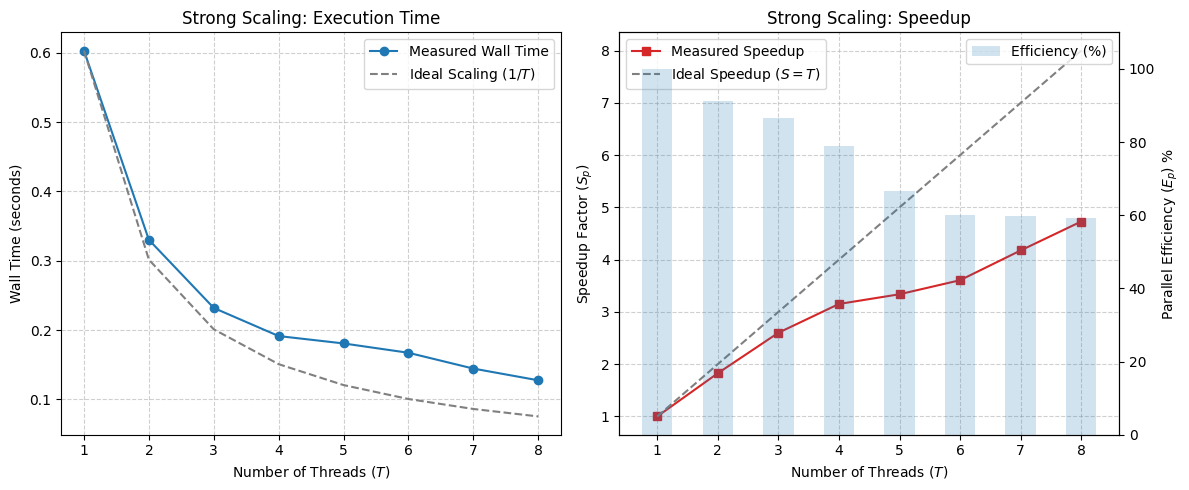

In [ ]:
threads = np.array([1, 2, 3, 4, 5,6,7,8])

# Wall times
# 1,000,000
times = np.array([0.603021, 0.330127, 0.231853, 0.191311, 0.180658,0.167195, 0.144401, 0.127493])
# 10000
times_1 = np.array([0.006633, 0.003648, 0.002495, 0.002347, 0.002072, 0.001703, 0.001519, 0.001322])
# --------------------------

# Calculations
speedup = times[0] / times
efficiency = (speedup / threads) * 100

# Plotting Configuration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Wall Time and Ideal Scaling
ax1.plot(threads, times, 'o-', label='Measured Wall Time')
ax1.plot(threads, times[0]/threads, '--', color='gray', label='Ideal Scaling ($1/T$)')
ax1.set_xlabel('Number of Threads ($T$)')
ax1.set_ylabel('Wall Time (seconds)')
ax1.set_title('Strong Scaling: Execution Time')
ax1.set_xticks(threads)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot 2: Speedup and Efficiency
ax2.plot(threads, speedup, 's-', color='tab:red', label='Measured Speedup')
ax2.plot(threads, threads, '--', color='gray', label='Ideal Speedup ($S=T$)')
ax2.set_xlabel('Number of Threads ($T$)')
ax2.set_ylabel('Speedup Factor ($S_p$)')
ax2.set_title('Strong Scaling: Speedup')
ax2.set_xticks(threads)

# Secondary axis for Efficiency
ax3 = ax2.twinx()
ax3.bar(threads, efficiency, alpha=0.2, color='tab:blue', width=0.5, label='Efficiency (%)')
ax3.set_ylabel('Parallel Efficiency ($E_p$) %')
ax3.set_ylim(0, 110)

ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')
ax3.legend(loc='upper right')

plt.tight_layout()
#plt.savefig('scaling_analysis.png', dpi=300)
#print("Plot saved as scaling_analysis.png")

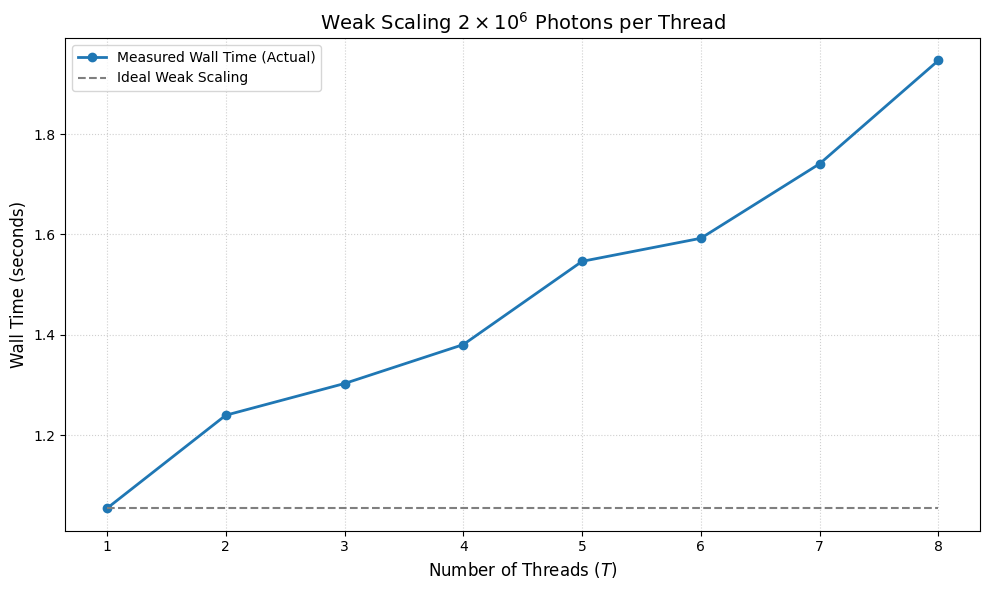

In [12]:
# --- DATA SELECTION: 2,000,000 photons per thread ---
threads = np.array([1, 2, 3, 4, 5, 6, 7, 8])
weak_times = np.array([1.054826, 1.240159, 1.303311, 1.380807, 1.546501, 1.592456, 1.740768, 1.94650])

# Calculations
ideal_time = np.full_like(threads, weak_times[0], dtype=float)

# Plotting
plt.figure(figsize=(10, 6))

# Plot Measured Wall Time
plt.plot(threads, weak_times, 'o-', color='#1f77b4', linewidth=2, label='Measured Wall Time (Actual)')

# Plot Ideal Wall Time (Horizontal Baseline)
plt.plot(threads, ideal_time, '--', color='#7f7f7f', label='Ideal Weak Scaling')

# Formatting
plt.title('Weak Scaling $2 \\times 10^6$ Photons per Thread', fontsize=14)
plt.xlabel('Number of Threads ($T$)', fontsize=12)
plt.ylabel('Wall Time (seconds)', fontsize=12)
plt.xticks(threads)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True)

# Interpretation Text Box (Optional for your report)
# plt.text(1.5, max(weak_times)*0.85, "Efficiency Loss ~46% at 8 Threads", 
#          bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
#plt.savefig('weak_scaling_final.png', dpi=300)
#print("Weak scaling plot generated successfully.")